In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from scripts.preprocessing.pipeline import process

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pandas.plotting import autocorrelation_plot

In [3]:
train, (sample_submission, test), dqc_report = process(data_dir="../data", save_report_path="report.json")

Report saved: report.json


In [4]:
train.describe()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id
count,2935821,2.935821e+06,2.935821e+06,2.935821e+06,2.935821e+06,2.935821e+06,2.935821e+06
mean,2014-04-03 05:44:57.946366208,1.456992e+01,3.300172e+01,1.019720e+04,8.908571e+02,1.245219e+00,4.000137e+01
min,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-02,0.000000e+00,0.000000e+00
25%,2013-08-01 00:00:00,7.000000e+00,2.200000e+01,4.476000e+03,2.490000e+02,1.000000e+00,2.800000e+01
50%,2014-03-04 00:00:00,1.400000e+01,3.100000e+01,9.343000e+03,3.990000e+02,1.000000e+00,4.000000e+01
75%,2014-12-05 00:00:00,2.300000e+01,4.700000e+01,1.568400e+04,9.990000e+02,1.000000e+00,5.500000e+01
max,2015-10-31 00:00:00,3.300000e+01,5.900000e+01,2.216900e+04,3.079800e+05,2.169000e+03,8.300000e+01
std,NaN,9.422983e+00,1.622699e+01,6.324297e+03,1.729807e+03,2.617059e+00,1.710079e+01


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935821 entries, 0 to 2935820
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   date                datetime64[ns]
 1   date_block_num      int64         
 2   shop_id             int64         
 3   item_id             int64         
 4   item_price          float64       
 5   item_cnt_day        float64       
 6   item_name           object        
 7   item_category_id    int64         
 8   item_category_name  object        
 9   shop_name           object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 224.0+ MB


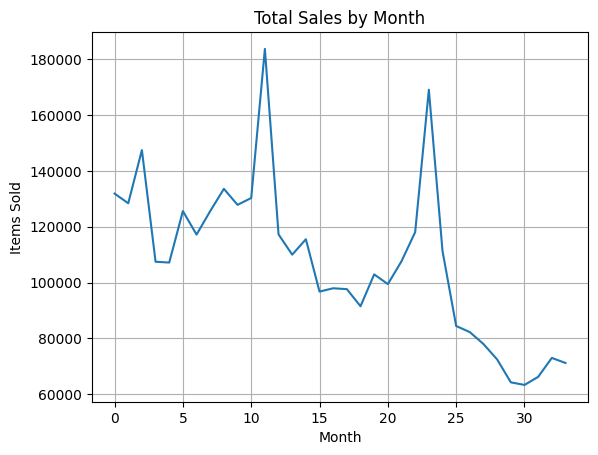

In [6]:
monthly_sales = train.groupby("date_block_num").item_cnt_day.sum()
plt.plot(monthly_sales)
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Items Sold")
plt.grid(True)
plt.show()

Пики на 11 и 23 месяцах — это декабрьский ажиотаж перед Новым годом. При этом общий тренд идет на спад.Для модели это значит, что месяц и общее падение спроса — самые важные фичи.

C:\Users\germa\AppData\Local\Temp\ipykernel_24448\786238927.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


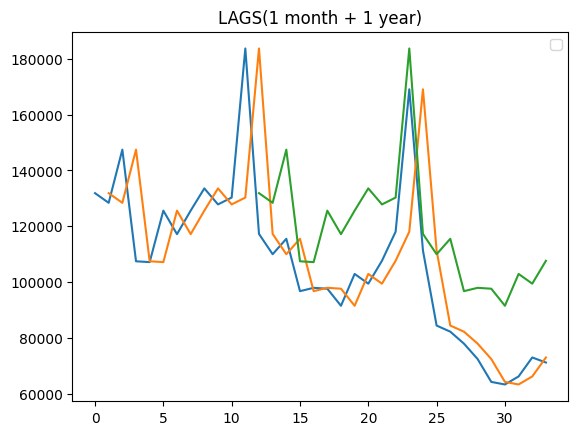

In [7]:
lag_month = monthly_sales.shift(1)
lag_year = monthly_sales.shift(12)

plt.plot(monthly_sales)
plt.plot(lag_month)
plt.plot(lag_year)
plt.legend()
plt.title("LAGS(1 month + 1 year)")
plt.show()

Тут видно, что лаг в 1 месяц (оранжевый) почти идеально повторяет график, но с задержкой. Лаг в 1 год (зеленый) ловит новогодние пики, подтверждая, что сезонность тут цикличная.

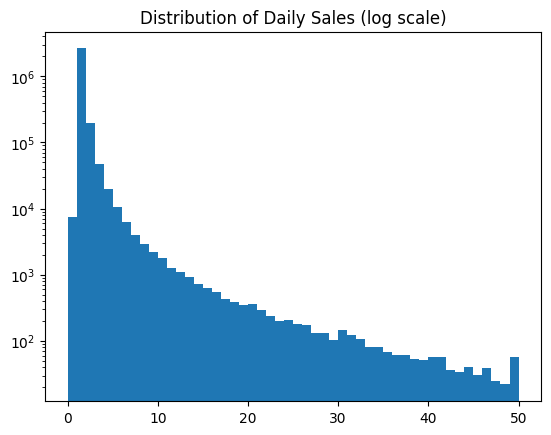

In [8]:
plt.hist(train["item_cnt_day"], bins=50, range=(0, 50))
plt.yscale("log")
plt.title("Distribution of Daily Sales (log scale)")
plt.show()

Логарифмическая шкала показывает, что почти все продажи это штучный товар (1–2 единицы в чеке).Так же на графике можно было проследить кучу редких выбросов и оптовых закупок из-за затухания и длинны графика, поэтому я клипал до 20.

In [9]:
item_life = train.groupby("item_id").agg(
    {
        "date_block_num": ["min","max"],
        "item_cnt_day": "sum"
    }
)
item_life

date_block_num     item_cnt_day
                   min max          sum
item_id                                
0                   20  20          1.0
1                   15  21          6.0
2                   19  22          2.0
3                   18  19          2.0
4                   20  20          1.0
...                ...  ..          ...
22165                7  16          2.0
22166                9  33        348.0
22167                8  33       1321.0
22168                0   8          6.0
22169               14  14          1.0

[21807 rows x 3 columns]

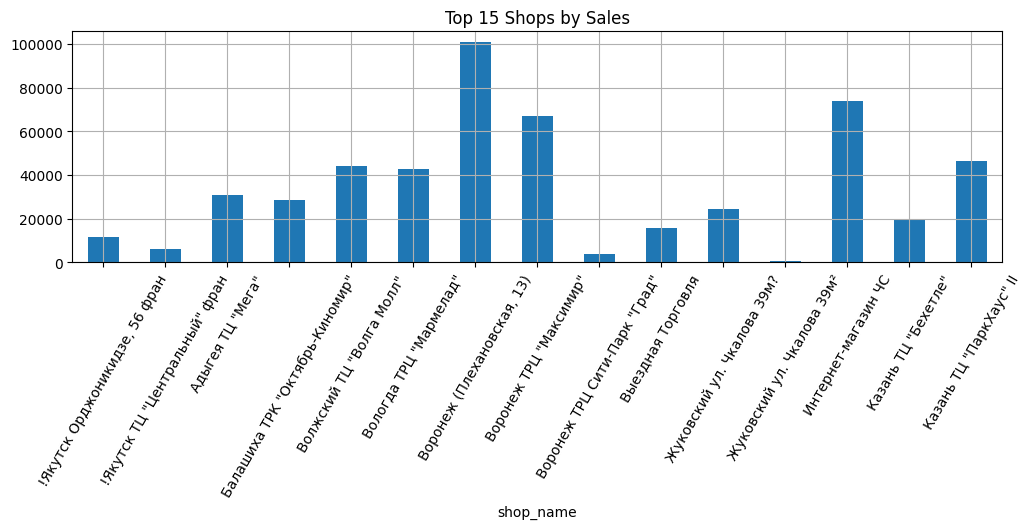

In [10]:
shop_sales = train.groupby("shop_name").item_cnt_day.sum().head(15)

plt.figure(figsize=(12,3))
shop_sales.plot(kind="bar")
plt.title("Top 15 Shops by Sales")
plt.xticks(rotation=60)
plt.grid(True)
plt.show()

Тут сразу видно, что пара магазинов из Воронежа явные лидеры.То есть продажи сильно зависят от конкретной точки, а не только от общей сезонности.А значит, что shop_id обязательная фича, потому что поведение у топовых ТЦ и маленьких точек будет абсолютно разным.

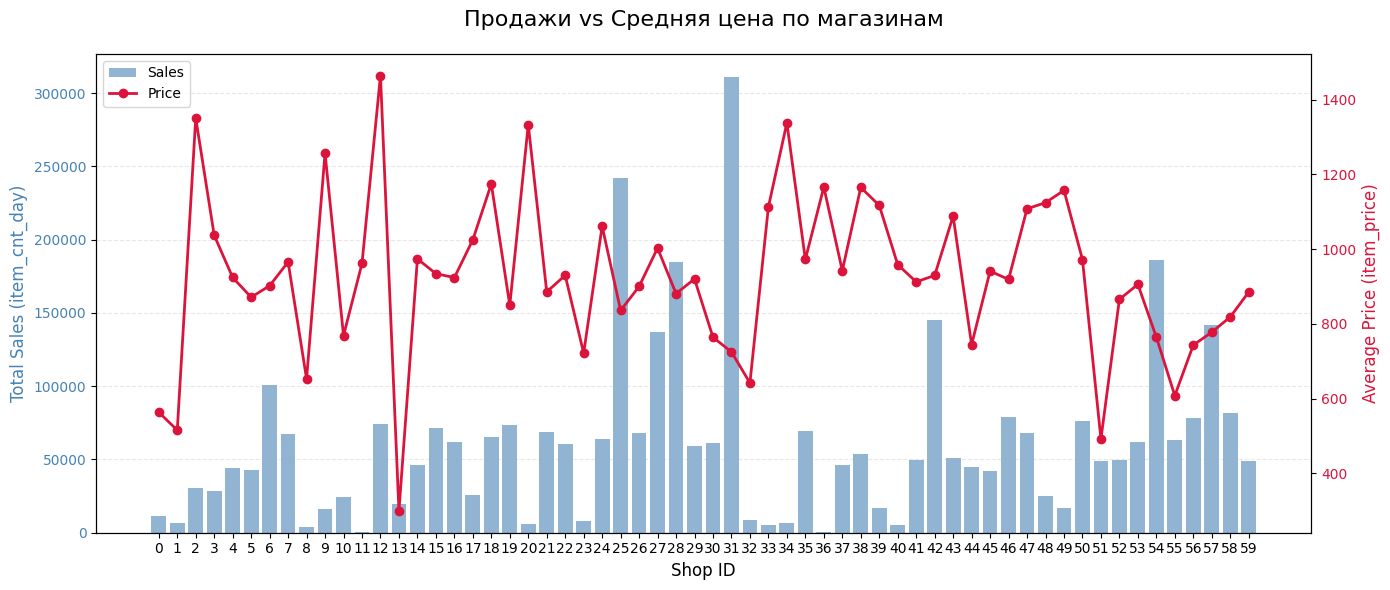

In [11]:
shop_profile = train.groupby("shop_id").agg(
    {
        "item_cnt_day":"sum",
        "item_price":"mean"
    }
)

fig, ax1 = plt.subplots(figsize=(14, 6))

color_sales = 'steelblue'
ax1.set_xlabel('Shop ID', fontsize=12)
ax1.set_ylabel('Total Sales (item_cnt_day)', color=color_sales, fontsize=12)
ax1.bar(shop_profile.index, shop_profile['item_cnt_day'], color=color_sales, alpha=0.6, label='Sales')
ax1.tick_params(axis='y', labelcolor=color_sales)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx() 
color_price = 'crimson'
ax2.set_ylabel('Average Price (item_price)', color=color_price, fontsize=12)
ax2.plot(shop_profile.index, shop_profile['item_price'], color=color_price, marker='o', linewidth=2, label='Price')
ax2.tick_params(axis='y', labelcolor=color_price)

plt.title('Продажи vs Средняя цена по магазинам', fontsize=16, pad=20)
plt.xticks(shop_profile.index)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

fig.tight_layout()
plt.show()

Прямой связи выше цена - меньше продаж нет.Например, в магазине 31 гигантские продажи при средней цене, а в 12 цена зашкаливает, но спроса почти ноль.Это значит, что выручка зависит не от дешевизны, а от локации ТЦ или ассортимента.

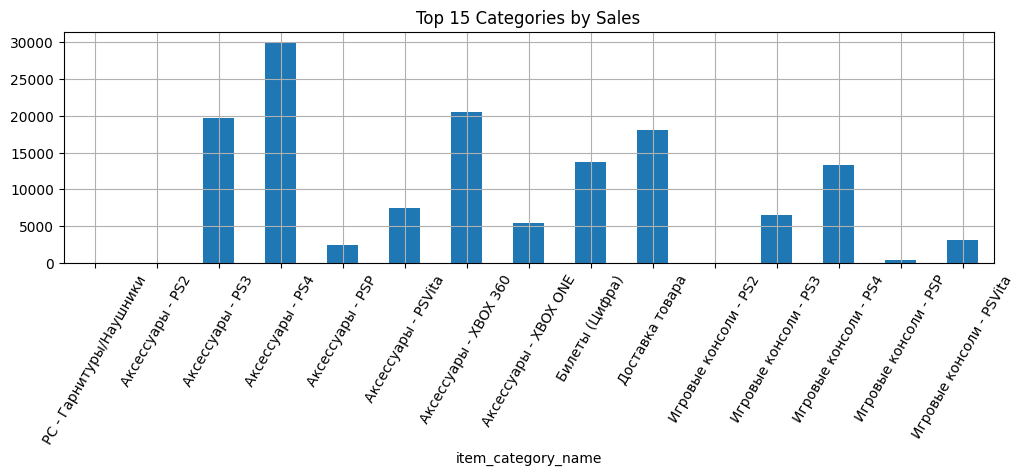

In [12]:
cat_sales = train.groupby("item_category_name").item_cnt_day.sum().head(15)

plt.figure(figsize=(12,3))
cat_sales.plot(kind="bar")
plt.title("Top 15 Categories by Sales")
plt.xticks(rotation=60)
plt.grid(True)
plt.show()

Абсолюьтными лидерами по датасету являются аксессуары для PS4 и Xbox 360, то есть остальные вещи продаются единциами.


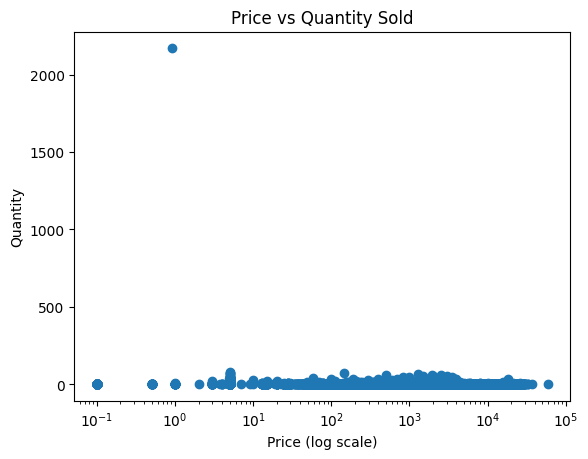

In [13]:
sample = train.sample(100000)
plt.scatter(sample.item_price, sample.item_cnt_day)
plt.xscale("log")
plt.title("Price vs Quantity Sold")
plt.xlabel("Price (log scale)")
plt.ylabel("Quantity")
plt.show()

Видно, что основная масса продаж это дешевые товары, но была пара выбросов с количеством 200+ до клиппинга до 20. Средней ценой можно назвать 10^3 с количеством 2.5, так как около нее наиболее равномерно разбросаны остальные точки. Все, что выбивается далеко вверх или вправо, можно обрезать или дропать, так как аномалии.


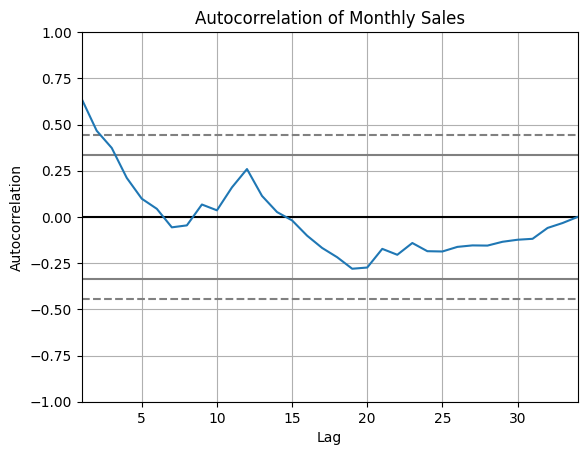

In [14]:
autocorrelation_plot(monthly_sales)
plt.title("Autocorrelation of Monthly Sales")
plt.show()

Автокорреляция подтверждает, что данные сильно зависят от прошлого. Высокое значение на первых лагах значит, что прошлый месяц хорошо предсказывает следующий, а скачок в районе 12 лага показывает годовую сезонность, что мы смотрели выше. То есть продажи сегодня это смесь того, что было месяц назад, и того, что было в это же время в прошлом году.


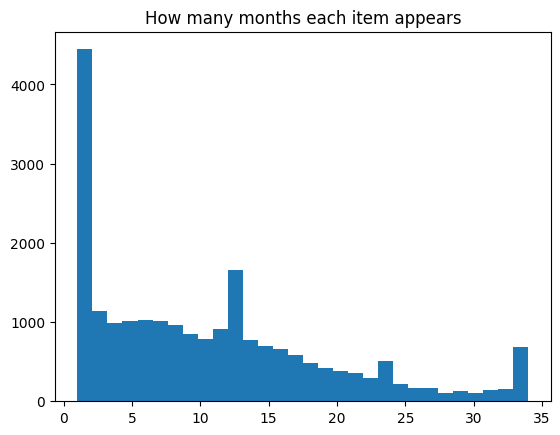

In [15]:
items_frequency = train.groupby("item_id").date_block_num.nunique()
plt.hist(items_frequency, bins=30)
plt.title("How many months each item appears")
plt.show()

Этот график показывает жизненный цикл товара. Видно по огромному бину слева, что большинство товаров появляются в продаже всего на пару месяцев и больше не возвращаются. То есть у большинства позиций нет долгой истории, поэтому одних только лагов будет недостаточно, придется опираться на признаки категорий, чтобы предсказывать данные товары.


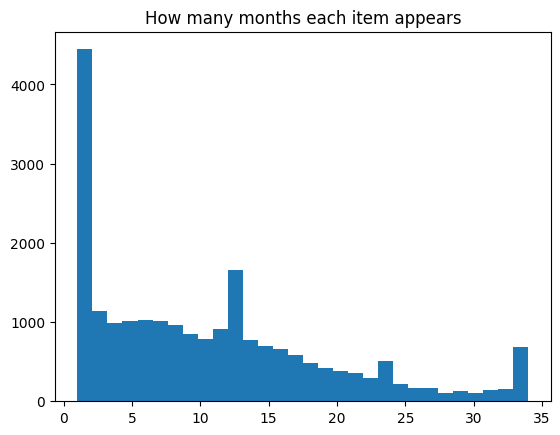

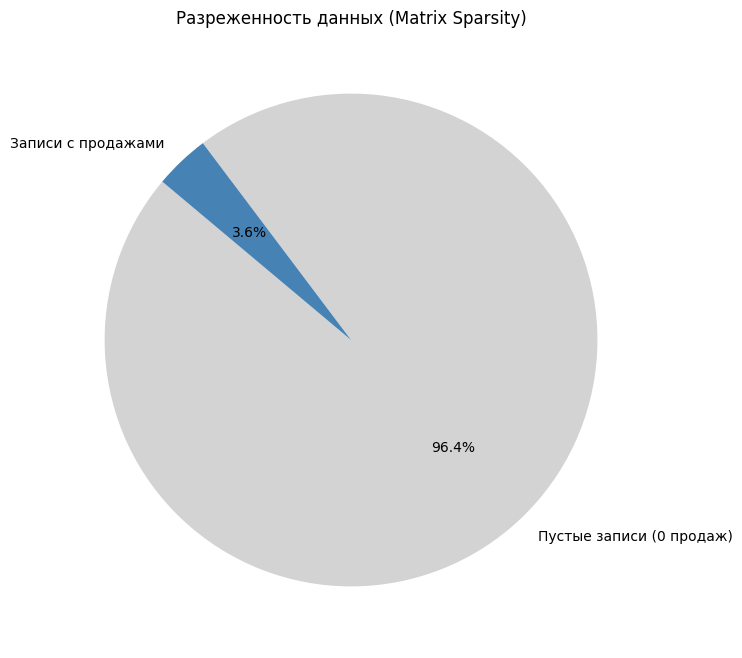

Всего возможных комбинаций: 44486280
Реальных фактов продаж: 1609124


In [16]:
items_frequency = train.groupby("item_id").date_block_num.nunique()
plt.hist(items_frequency, bins=30)
plt.title("How many months each item appears")
plt.show()

n_shops = train['shop_id'].nunique()
n_items = train['item_id'].nunique()
n_months = train['date_block_num'].nunique()

total_combinations = n_shops * n_items * n_months
actual_sales = train.groupby(['date_block_num', 'shop_id', 'item_id']).size().shape[0]

labels = ['Пустые записи (0 продаж)', 'Записи с продажами']
sizes = [total_combinations - actual_sales, actual_sales]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightgray', 'steelblue'])
plt.title('Разреженность данных (Matrix Sparsity)')
plt.show()

print(f"Всего возможных комбинаций: {total_combinations}")
print(f"Реальных фактов продаж: {actual_sales}")


Видно только 3.6% реальных фактов продаж(а нам было бы идеально иметь декартово произведение между товарами и магазинами). Если мы будем учить модель только на этих данных, она станет будет думать, что нулей никогда нет и никогда не научится предсказывать отсутствие спроса.
